# Equation-Based SIR Model
## Lesson 3 · Section 1

In this notebook you will build and test the classical **SIR epidemic model** step by step.

We will:
1. Explain the meaning of the compartments `S`, `I`, and `R`
2. Translate the equations into Python functions
3. Test small parts of the model independently
4. Implement a simple Euler simulation
5. Visualise epidemic curves
6. Explore how the parameters change the outbreak
7. End with ideas for further independent work

The notebook is designed to be **educational**: each section contains small pieces that you can run and modify on your own.


## 0 · Imports
We only use NumPy and Matplotlib so the notebook stays simple and transparent.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

print('Imports loaded successfully ✓')


Imports loaded successfully ✓


---
## 1 · The SIR idea

The classical SIR model divides the population into three groups:

- `S` = susceptible individuals
- `I` = infected and infectious individuals
- `R` = recovered individuals

The model equations are:

$$\frac{dS}{dt} = -\beta S I$$
$$\frac{dI}{dt} = \beta S I - \gamma I$$
$$\frac{dR}{dt} = \gamma I$$

where:

- `β` is the infection rate
- `γ` is the recovery rate

### Interpretation
- New infections move people from `S` to `I`
- Recoveries move people from `I` to `R`
- The total population should remain constant: `S + I + R = N`


## 2 · Parameters and initial conditions
Keep all important values in one place so you can easily experiment later.


In [2]:
beta = 0.35
gamma = 0.10

S0 = 0.99
I0 = 0.01
R0 = 0.00

T = 160
dt = 0.1

R_basic = beta / gamma

print(f'beta = {beta}')
print(f'gamma = {gamma}')
print(f'Basic reproduction number R0 = beta/gamma = {R_basic:.2f}')
print(f'Initial total population = {S0 + I0 + R0:.2f}')


beta = 0.35
gamma = 0.1
Basic reproduction number R0 = beta/gamma = 3.50
Initial total population = 1.00


---
## 3 · Write the differential equations as a Python function
This function does not simulate the epidemic yet. It only computes the **instantaneous rate of change** for one state `(S, I, R)`.

This is an important teaching step: first understand the model locally, then simulate it over time.


In [3]:
def sir_rhs(S, I, R, beta, gamma):
    """Return the rates of change dS/dt, dI/dt, dR/dt."""
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I
    return dS, dI, dR

example = sir_rhs(S=0.99, I=0.01, R=0.0, beta=beta, gamma=gamma)
print('Rates for the initial state:', example)


Rates for the initial state: (-0.0034649999999999998, 0.0024649999999999997, 0.001)


### Independent test 1
Try a simple consistency check. If nobody is infected (`I = 0`), then nothing should change.


In [4]:
test_result = sir_rhs(S=1.0, I=0.0, R=0.0, beta=0.5, gamma=0.2)
print('Test result:', test_result)
assert test_result == (-0.0, 0.0, 0.0)
print('Test passed ✓ No infected people means no epidemic dynamics.')


Test result: (-0.0, 0.0, 0.0)
Test passed ✓ No infected people means no epidemic dynamics.


---
## 4 · One Euler step
The Euler method approximates the continuous system by small jumps in time:

$$X_{t+\Delta t} \approx X_t + \Delta t \cdot \frac{dX}{dt}$$

We first implement **one step only**, because this is easier to understand and test than writing the whole simulation at once.


In [5]:
def euler_step_sir(S, I, R, beta, gamma, dt):
    dS, dI, dR = sir_rhs(S, I, R, beta, gamma)
    S_new = S + dt * dS
    I_new = I + dt * dI
    R_new = R + dt * dR
    return S_new, I_new, R_new

S1, I1, R1 = euler_step_sir(S0, I0, R0, beta, gamma, dt=1.0)
print(f'After one step: S={S1:.4f}, I={I1:.4f}, R={R1:.4f}')


After one step: S=0.9865, I=0.0125, R=0.0010


### Independent test 2
Check that one Euler step still approximately preserves the total population.


In [6]:
before = S0 + I0 + R0
after = S1 + I1 + R1
print(f'Total before = {before:.6f}')
print(f'Total after  = {after:.6f}')
assert np.isclose(before, after)
print('Test passed ✓ Population is conserved in this step.')


Total before = 1.000000
Total after  = 1.000000
Test passed ✓ Population is conserved in this step.


---
## 5 · Full simulation loop
Now we repeat the Euler step many times and store the full epidemic history.


In [7]:
def simulate_sir_euler(S0, I0, R0, beta, gamma, T, dt):
    steps = int(T / dt) + 1
    t = np.linspace(0, T, steps)
    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)

    S[0], I[0], R[0] = S0, I0, R0

    for k in range(1, steps):
        S[k], I[k], R[k] = euler_step_sir(S[k - 1], I[k - 1], R[k - 1], beta, gamma, dt)

    return t, S, I, R

t, S, I, R = simulate_sir_euler(S0, I0, R0, beta, gamma, T, dt)
print(f'Simulation finished with {len(t)} stored time points.')


Simulation finished with 1601 stored time points.


### Independent test 3
Check that the whole simulation conserves the total population over time.


In [8]:
total_population = S + I + R
print('Minimum total:', total_population.min())
print('Maximum total:', total_population.max())
assert np.allclose(total_population, total_population[0])
print('Test passed ✓ The total population remains constant throughout the simulation.')


Minimum total: 0.9999999999999989
Maximum total: 1.000000000000001
Test passed ✓ The total population remains constant throughout the simulation.


---
## 6 · Plot the epidemic curves
This is the classical SIR output: susceptible falls, infected rises and then falls, recovered increases.


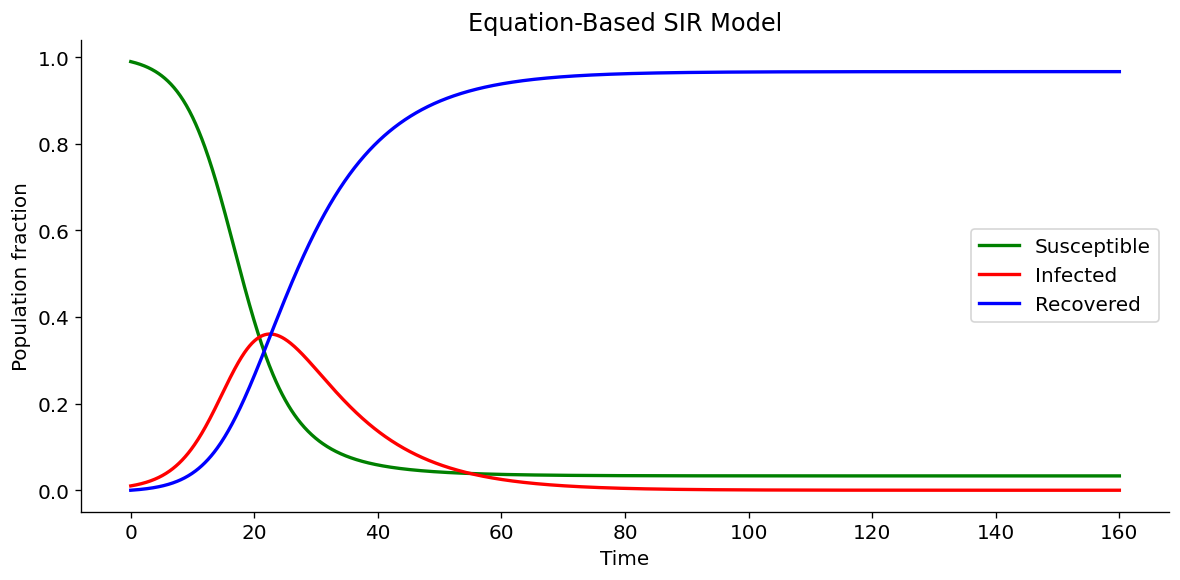

Peak infected fraction = 0.361 at time t = 22.5


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, S, label='Susceptible', color='green', linewidth=2)
ax.plot(t, I, label='Infected', color='red', linewidth=2)
ax.plot(t, R, label='Recovered', color='blue', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Population fraction')
ax.set_title('Equation-Based SIR Model')
ax.legend()
plt.tight_layout()
plt.show()

peak_index = np.argmax(I)
print(f'Peak infected fraction = {I[peak_index]:.3f} at time t = {t[peak_index]:.1f}')


## 7 · A small guided experiment
The parameter ratio `beta/gamma` is very important. If it is large, the disease spreads more easily.

Try the prepared values below and compare the curves.


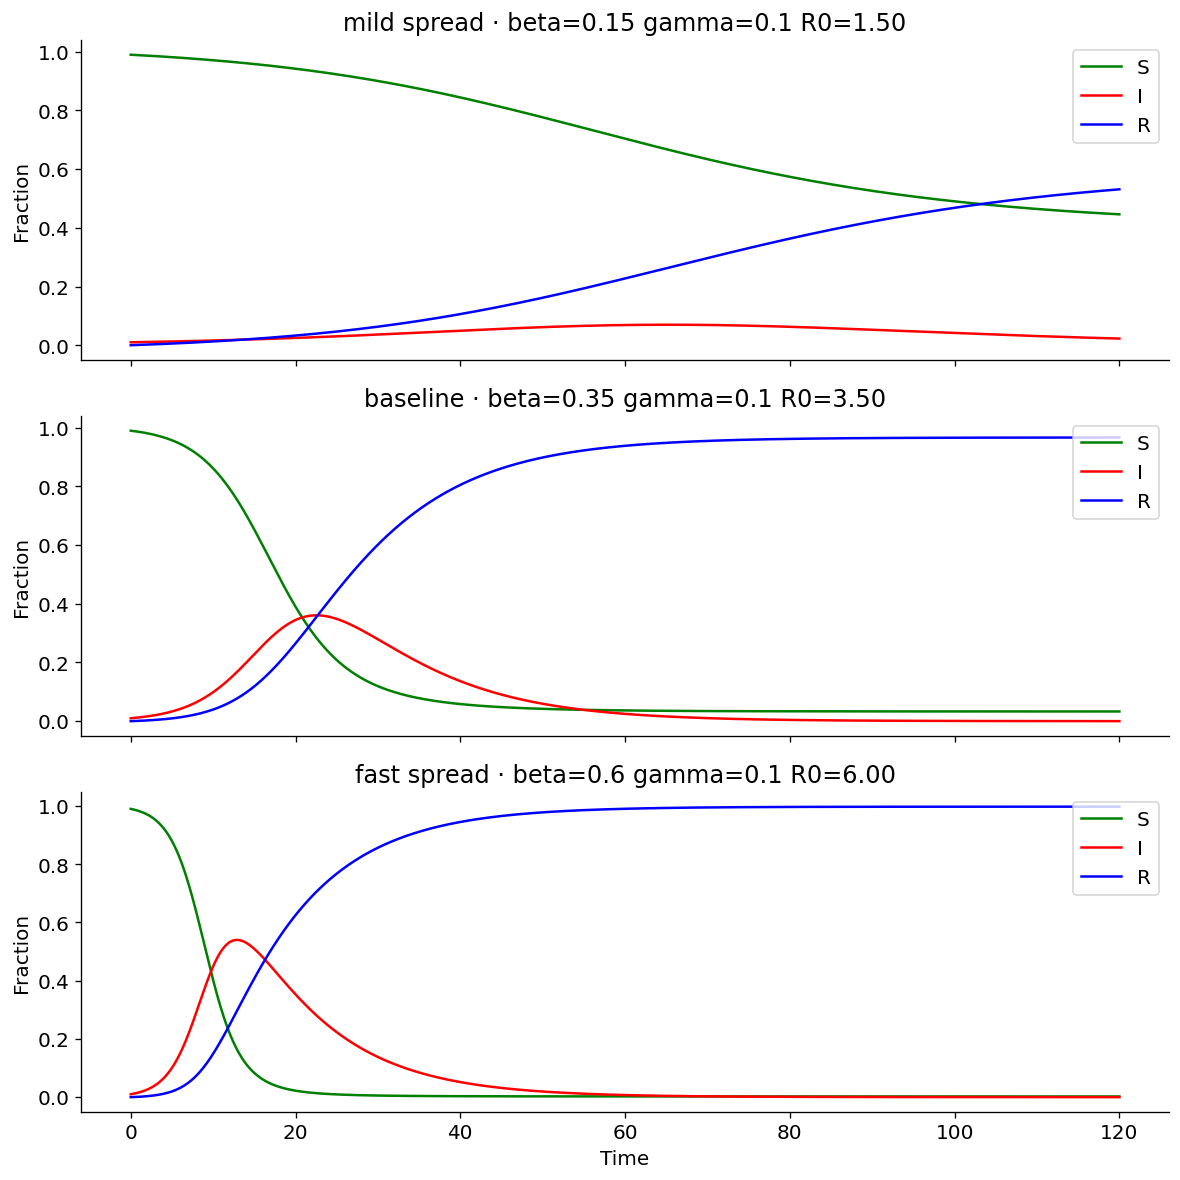

In [10]:
parameter_sets = [
    {'beta': 0.15, 'gamma': 0.10, 'label': 'mild spread'},
    {'beta': 0.35, 'gamma': 0.10, 'label': 'baseline'},
    {'beta': 0.60, 'gamma': 0.10, 'label': 'fast spread'},
]

fig, axes = plt.subplots(len(parameter_sets), 1, figsize=(10, 10), sharex=True)

for ax, params in zip(axes, parameter_sets):
    t_tmp, S_tmp, I_tmp, R_tmp = simulate_sir_euler(
        S0, I0, R0, params['beta'], params['gamma'], T=120, dt=0.1
    )
    ax.plot(t_tmp, S_tmp, color='green', label='S')
    ax.plot(t_tmp, I_tmp, color='red', label='I')
    ax.plot(t_tmp, R_tmp, color='blue', label='R')
    ax.set_title(
        f"{params['label']} · beta={params['beta']} gamma={params['gamma']} R0={params['beta'] / params['gamma']:.2f}"
    )
    ax.set_ylabel('Fraction')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()


---
## 7c · The SIS Model and Stability Analysis

In the **SIS model**, recovered individuals become susceptible again (no lasting immunity):

$$\frac{dI}{dt} = \beta (1 - I) I - \gamma I = (\beta - \gamma) I - \beta I^2$$

**Equilibria** (set $dI/dt = 0$):

$$I^* \left[(\beta - \gamma) - \beta I^*\right] = 0$$

This gives two equilibria:
- $I_1^* = 0$ (disease-free)
- $I_2^* = 1 - \gamma/\beta = 1 - 1/R_0$ (endemic)

**Stability**:
- If $R_0 < 1$: only the disease-free equilibrium exists and is **stable**
- If $R_0 > 1$: the endemic equilibrium exists and is **stable**

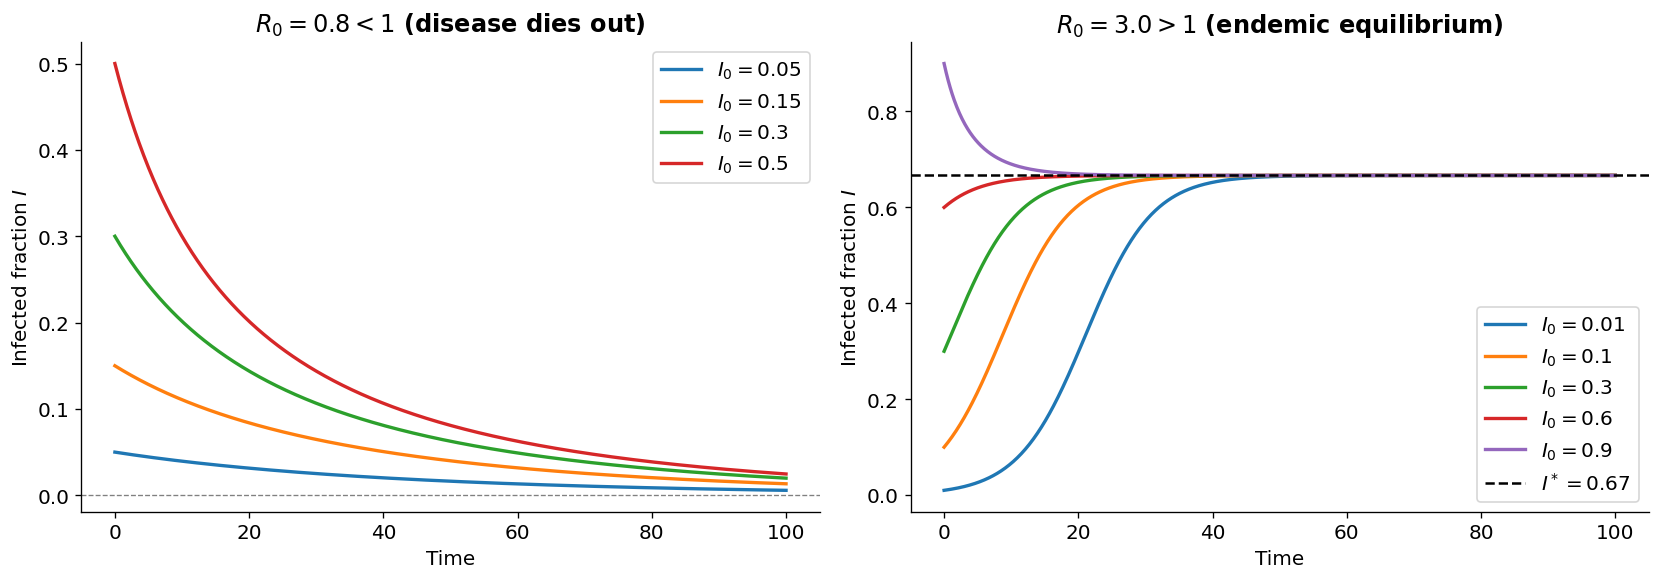

When R0 > 1, all initial conditions converge to I* = 1 - 1/R0 = 0.667
This is the key result of the SIS stability analysis.


In [12]:
def simulate_sis_euler(I0, beta, gamma, T, dt=0.1):
    """Simulate the SIS model: dI/dt = beta*(1-I)*I - gamma*I."""
    steps = int(T / dt) + 1
    t = np.linspace(0, T, steps)
    I = np.zeros(steps)
    I[0] = I0
    for k in range(1, steps):
        I[k] = I[k-1] + dt * (beta * (1 - I[k-1]) * I[k-1] - gamma * I[k-1])
    return t, I

# --- R0 < 1: disease dies out ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

beta_low, gamma_sis = 0.08, 0.10
R0_low = beta_low / gamma_sis
for I0 in [0.05, 0.15, 0.30, 0.50]:
    t_sis, I_sis = simulate_sis_euler(I0, beta_low, gamma_sis, T=100)
    ax1.plot(t_sis, I_sis, lw=2, label=f'$I_0 = {I0}$')
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.set_title(f'$R_0 = {R0_low:.1f} < 1$ (disease dies out)', fontweight='bold')
ax1.set_xlabel('Time')
ax1.set_ylabel('Infected fraction $I$')
ax1.legend()

# --- R0 > 1: endemic equilibrium ---
beta_high = 0.30
R0_high = beta_high / gamma_sis
endemic_eq = 1 - gamma_sis / beta_high
for I0 in [0.01, 0.10, 0.30, 0.60, 0.90]:
    t_sis, I_sis = simulate_sis_euler(I0, beta_high, gamma_sis, T=100)
    ax2.plot(t_sis, I_sis, lw=2, label=f'$I_0 = {I0}$')
ax2.axhline(endemic_eq, color='black', ls='--', lw=1.5, label=f'$I^* = {endemic_eq:.2f}$')
ax2.set_title(f'$R_0 = {R0_high:.1f} > 1$ (endemic equilibrium)', fontweight='bold')
ax2.set_xlabel('Time')
ax2.set_ylabel('Infected fraction $I$')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'When R0 > 1, all initial conditions converge to I* = 1 - 1/R0 = {endemic_eq:.3f}')
print('This is the key result of the SIS stability analysis.')

---
## 7d · R₀ and the Epidemic Threshold

The **basic reproduction number** $R_0 = \beta / \gamma$ determines whether an epidemic occurs.

At the start of an outbreak, $S \approx 1$, so:

$$\frac{dI}{dt} \approx (\beta - \gamma) I = \gamma (R_0 - 1) I$$

- If $R_0 > 1$: infected count grows exponentially → **epidemic**
- If $R_0 < 1$: infected count decays → **no epidemic**

### Herd Immunity Threshold

The epidemic peak occurs when $dI/dt = 0$, i.e. $S^* = 1/R_0$.

The fraction that must be immune to prevent an epidemic:

$$p_{\mathrm{herd}} = 1 - \frac{1}{R_0}$$

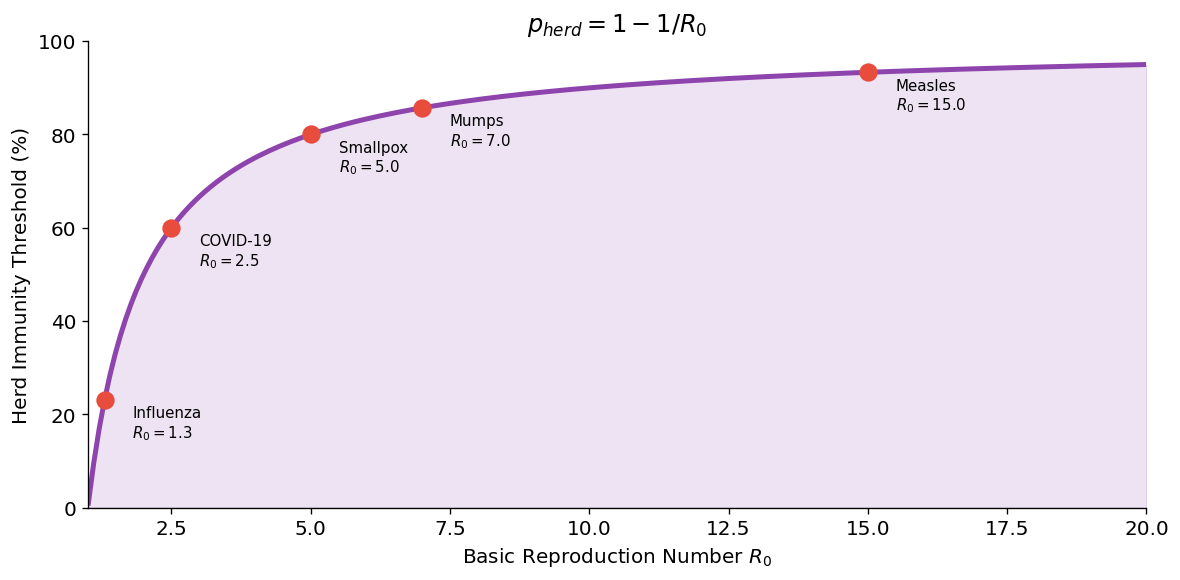

For our baseline R0 = 3.50:
  Herd immunity threshold = 71.4%


In [13]:
# Herd immunity threshold visualization
R0_range = np.linspace(1.01, 20, 200)
p_herd = 1 - 1 / R0_range

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(R0_range, p_herd * 100, color='#8e44ad', lw=3)
ax.fill_between(R0_range, p_herd * 100, alpha=0.15, color='#8e44ad')

diseases = [('Influenza', 1.3), ('COVID-19', 2.5), ('Smallpox', 5.0),
            ('Mumps', 7.0), ('Measles', 15.0)]
for name, r0 in diseases:
    p = (1 - 1/r0) * 100
    ax.plot(r0, p, 'o', markersize=10, color='#e74c3c', zorder=5)
    ax.annotate(f'{name}\n$R_0={r0}$', xy=(r0, p),
                xytext=(r0 + 0.5, p - 8), fontsize=9)

ax.set_xlabel('Basic Reproduction Number $R_0$')
ax.set_ylabel('Herd Immunity Threshold (%)')
ax.set_title('$p_{herd} = 1 - 1/R_0$', fontweight='bold')
ax.set_xlim(1, 20)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# Compute for our baseline parameters
print(f'For our baseline R0 = {beta/gamma:.2f}:')
print(f'  Herd immunity threshold = {(1 - 1/(beta/gamma))*100:.1f}%')

---
## 7e · Final Size of the SIR Epidemic

An elegant result: we can compute the **total fraction infected** without solving the full ODE.

Dividing $dS/dR$:

$$\frac{dS}{dR} = \frac{-\beta S I}{\gamma I} = -R_0 S \quad \Rightarrow \quad S(t) = S_0 \, e^{-R_0 \, R(t)}$$

At the end ($I \to 0$, $R_\infty = 1 - S_\infty$):

$$S_\infty = S_0 \, e^{-R_0 (1 - S_\infty)}$$

This is a transcendental equation that we solve numerically.

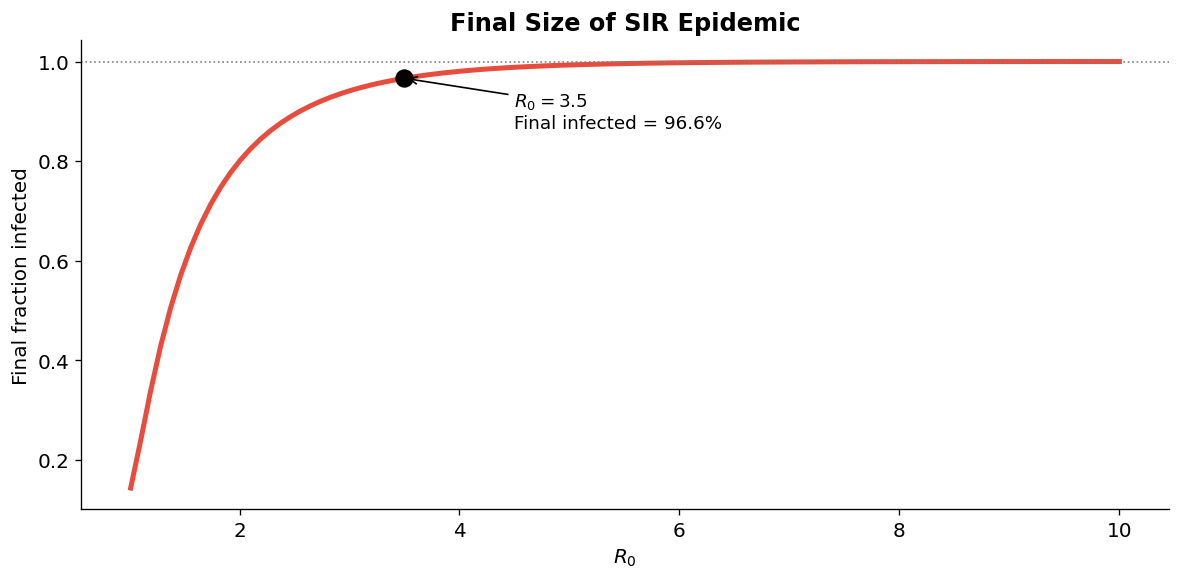

Analytical final size (R0=3.5): 0.9664
Simulation final R:                      0.9669
Difference:                              0.0005


In [14]:
from scipy.optimize import fsolve

def final_size_equation(S_inf, S0, R0_val):
    """f(S_inf) = 0 when S_inf = S0 * exp(-R0 * (1 - S_inf))."""
    return S_inf - S0 * np.exp(-R0_val * (1 - S_inf))

# Compute final size for a range of R0 values
R0_vals = np.linspace(1.01, 10, 100)
final_fracs = []
for r0 in R0_vals:
    S_inf = fsolve(final_size_equation, 0.01, args=(0.99, r0))[0]
    final_fracs.append(1 - S_inf)  # fraction who got infected

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(R0_vals, final_fracs, color='#e74c3c', lw=3)
ax.set_xlabel('$R_0$')
ax.set_ylabel('Final fraction infected')
ax.set_title('Final Size of SIR Epidemic', fontweight='bold')
ax.axhline(1, color='gray', ls=':', lw=1)

# Mark our baseline
R0_base = beta / gamma
S_inf_base = fsolve(final_size_equation, 0.01, args=(0.99, R0_base))[0]
ax.plot(R0_base, 1 - S_inf_base, 'o', color='black', markersize=10, zorder=5)
ax.annotate(f'$R_0 = {R0_base:.1f}$\nFinal infected = {1-S_inf_base:.1%}',
            xy=(R0_base, 1-S_inf_base), xytext=(R0_base+1, 1-S_inf_base-0.1),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)

plt.tight_layout()
plt.show()

# Verify against simulation
print(f'Analytical final size (R0={R0_base:.1f}): {1-S_inf_base:.4f}')
print(f'Simulation final R:                      {R[-1]:.4f}')
print(f'Difference:                              {abs(R[-1] - (1-S_inf_base)):.4f}')

## 8 · What to try next
Run the previous cells again after changing one parameter at a time.

Suggested experiments:

- Increase `beta` and observe what happens to the infection peak
- Increase `gamma` and observe whether the outbreak ends faster
- Change `I0` from `0.01` to `0.10` and compare the start of the epidemic
- Change `dt` from `0.1` to `0.5` and discuss numerical accuracy
- Try `beta < gamma` and check whether the epidemic grows strongly or not

### Write your own conclusions
For each experiment, answer:
1. What changed in the graph?
2. Did the infection peak become higher or lower?
3. Did the epidemic last longer or shorter?
4. Which parameter had the strongest effect?


---
## 9 · Independent work and mini-project ideas
Choose one or more of the following projects for independent work.

### Project A · Add births and deaths
Extend the model so the total population is no longer constant.

### Project B · Add vaccination
Move part of the susceptible population directly to `R` at the beginning or during the simulation.

### Project C · Compare SIR and SIS
Modify the recovery rule so recovered individuals become susceptible again.

### Project D · Compute useful summary values
Write code that automatically reports:
- time of infection peak
- size of infection peak
- final recovered fraction

### Project E · Explore numerical methods
Implement a second-order method and compare it with Euler.

### Final reflection
After finishing, explain in your own words:
- What assumptions the equation-based SIR model makes
- What the model can explain well
- What the model cannot capture well
- Why an agent-based approach might be useful in some situations
